In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
df=pd.read_csv('sales_data.csv')

In [121]:
df

,Region,Product,Price,Promotion,Sales_Units
0,North,A,100,1,420
1,North,A,110,1,395
2,North,A,120,0,360
3,North,B,130,1,340
4,North,B,140,0,310
5,South,A,95,1,450
6,South,A,105,1,420
7,South,A,115,0,380
8,South,B,125,1,360
9,South,B,135,0,330


EDA

In [122]:
df.head()

,Region,Product,Price,Promotion,Sales_Units
0,North,A,100,1,420
1,North,A,110,1,395
2,North,A,120,0,360
3,North,B,130,1,340
4,North,B,140,0,310


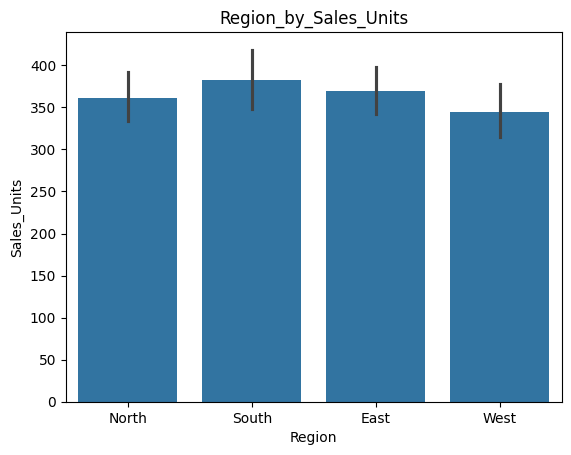

In [123]:
sns.barplot(x='Region',y='Sales_Units',data=df)
plt.title('Region_by_Sales_Units')
plt.show()

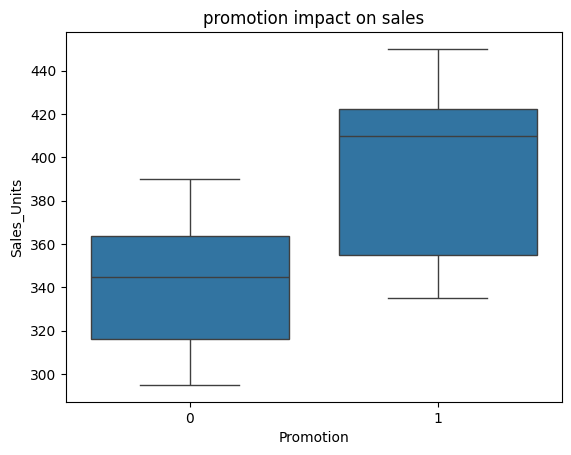

In [124]:
sns.boxplot(x='Promotion',y='Sales_Units',data=df)
plt.title('promotion impact on sales')
plt.show()

HYPOTHESIS TESTING USING T-TEST

In [125]:
from scipy.stats import ttest_ind

In [126]:
promo=df[df['Promotion']==1]['Sales_Units']
nopromo=df[df['Promotion']==0]['Sales_Units']

In [127]:
t_stat,p_value=ttest_ind(promo,nopromo)

In [128]:
print('t_stat:',t_stat)
print('p_value:',p_value)

t_stat: 3.6357053395555146
p_value: 0.001383475560996724


In [129]:
alpha=0.05

In [130]:
if p_value<alpha:
    print('Result is Significant')
else:
    print('Result is not Significant')

Result is Significant


CORRELATION

In [131]:
print(df[["Price","Sales_Units"]].corr())

                Price  Sales_Units
Price        1.000000    -0.948518
Sales_Units -0.948518     1.000000


MODEL TRAINING

In [132]:
x=pd.get_dummies(df[["Region","Product","Price","Promotion"]],drop_first=True)

In [133]:
y=df[['Sales_Units']]

In [134]:
from sklearn.model_selection import train_test_split

In [135]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [136]:
from sklearn.linear_model import LinearRegression


In [137]:
model=LinearRegression()

In [138]:
model.fit(x_train,y_train)

LinearRegression()

In [139]:
model.score(x_train,y_train)

0.9892799528764097

In [140]:
model.score(x_test,y_test)

0.9684069791711458

PREDICTION

In [141]:
new_data=pd.DataFrame({'Region':['North'],
                      'Product':['A'],
                      'Price':[100],
                      'Promotion':[1]})

In [142]:
encoded=pd.get_dummies(new_data,drop_first=True)

In [143]:
final=encoded.reindex(columns=x.columns,fill_value=0)

In [144]:
model.predict(final)

array([[411.55536691]])

In [153]:
model.predict(final)[0].round(1)

array([411.6])

5% DISCOUNT SCENARIO 

In [154]:
original_price=130

In [155]:
dis_price=original_price*0.95

dis_scenario=pd.DataFrame({"Region":["South"],
                          "Product":["A"],
                          "Price":[dis_price],
                          "Promotion":[1]})

In [156]:
dis_encode1=pd.get_dummies(dis_scenario,drop_first=True)

In [157]:
dis_encode=dis_encode1.reindex(columns=x.columns,fill_value=0) #column match krne ke liye aur missing value 0 se fill krne ke liye


In [158]:
prediction=model.predict(dis_encode)

In [159]:
int(prediction[0])

C:\Users\Arbaz Nadaf\AppData\Local\Temp\ipykernel_8352\3908850228.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  int(prediction[0])


369